In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load Cleaned Dataset</h2>

In [3]:
DATA_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Rows: {len(df):,}")

Rows: 1,010,535


<h2>Keep Identified Customers</h2>

In [4]:
cohort_df = df[
    df["CustomerID"].notna()
].copy()

print(
    f"Identified-customer transactions: "
    f"{len(cohort_df):,}"
)

print(
    f"Unique customers: "
    f"{cohort_df['CustomerID'].nunique():,}"
)

Identified-customer transactions: 779,495
Unique customers: 5,881


<h2>Create Transaction Month</h2>

In [5]:
cohort_df["InvoiceMonth"] = (
    cohort_df["InvoiceDate"]
    .dt.to_period("M")
)

cohort_df[
    [
        "CustomerID",
        "InvoiceDate",
        "InvoiceMonth"
    ]
].head()

,CustomerID,InvoiceDate,InvoiceMonth
0,"13,085.00",2009-12-01 07:45:00,2009-12
1,"13,085.00",2009-12-01 07:45:00,2009-12
2,"13,085.00",2009-12-01 07:45:00,2009-12
3,"13,085.00",2009-12-01 07:45:00,2009-12
4,"13,085.00",2009-12-01 07:45:00,2009-12


<h2>Determine Each Customer's Cohort Month</h2>

In [6]:
customer_cohort = (
    cohort_df
    .groupby("CustomerID")["InvoiceMonth"]
    .min()
    .reset_index()
)

customer_cohort.columns = [
    "CustomerID",
    "CohortMonth"
]

customer_cohort.head(10)

,CustomerID,CohortMonth
0,"12,346.00",2009-12
1,"12,347.00",2010-10
2,"12,348.00",2010-09
3,"12,349.00",2010-04
4,"12,350.00",2011-02
5,"12,351.00",2010-11
6,"12,352.00",2010-11
7,"12,353.00",2010-10
8,"12,354.00",2011-04
9,"12,355.00",2010-05


<h2>Merge Cohort Information</h2>

In [7]:
cohort_df = cohort_df.merge(
    customer_cohort,
    on="CustomerID",
    how="left"
)

cohort_df[
    [
        "CustomerID",
        "InvoiceMonth",
        "CohortMonth"
    ]
].head(10)

,CustomerID,InvoiceMonth,CohortMonth
0,"13,085.00",2009-12,2009-12
1,"13,085.00",2009-12,2009-12
2,"13,085.00",2009-12,2009-12
3,"13,085.00",2009-12,2009-12
4,"13,085.00",2009-12,2009-12
5,"13,085.00",2009-12,2009-12
6,"13,085.00",2009-12,2009-12
7,"13,085.00",2009-12,2009-12
8,"13,085.00",2009-12,2009-12
9,"13,085.00",2009-12,2009-12


<h2>Calculate Cohort Index</h2>
Customer joins January

January  → Month 0
February → Month 1
March    → Month 2
April    → Month 3

In [8]:
cohort_df["CohortIndex"] = (
    (cohort_df["InvoiceMonth"].dt.year -
     cohort_df["CohortMonth"].dt.year) * 12
    +
    (cohort_df["InvoiceMonth"].dt.month -
     cohort_df["CohortMonth"].dt.month)
)

In [9]:
cohort_df[
    [
        "CustomerID",
        "InvoiceMonth",
        "CohortMonth",
        "CohortIndex"
    ]
].head(20)

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,"13,085.00",2009-12,2009-12,0
1,"13,085.00",2009-12,2009-12,0
2,"13,085.00",2009-12,2009-12,0
3,"13,085.00",2009-12,2009-12,0
4,"13,085.00",2009-12,2009-12,0
5,"13,085.00",2009-12,2009-12,0
6,"13,085.00",2009-12,2009-12,0
7,"13,085.00",2009-12,2009-12,0
8,"13,085.00",2009-12,2009-12,0
9,"13,085.00",2009-12,2009-12,0


<h2>Validate Cohort Index</h2>
The first purchase should always have: CohortIndex = 0

In [10]:
cohort_df["CohortIndex"].min()

np.int64(0)

In [11]:
cohort_df["CohortIndex"].value_counts().sort_index().head(10)

CohortIndex
0    165522
1     39288
2     39501
3     40177
4     35627
5     33743
6     32318
7     30724
8     27913
9     28199
Name: count, dtype: int64

<h2>Build Customer Retention Matrix</h2>

In [12]:
cohort_data = (
    cohort_df
    .groupby(
        [
            "CohortMonth",
            "CohortIndex"
        ]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_data.head(20)

,CohortMonth,CohortIndex,CustomerID
0,2009-12,0,955
1,2009-12,1,337
2,2009-12,2,319
3,2009-12,3,406
4,2009-12,4,363
5,2009-12,5,343
6,2009-12,6,360
7,2009-12,7,327
8,2009-12,8,321
9,2009-12,9,346


<h2>Create Retention Matrix</h2>

In [13]:
retention_matrix = (
    cohort_data
    .pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="CustomerID"
    )
)

retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,955.00,337.00,319.00,406.00,363.00,343.00,360.00,327.00,321.00,346.00,403.00,473.00,359.00,270.00,233.00,289.00,251.00,289.00,270.00,248.00,244.00,301.00,291.00,389.00,188.00
2010-01,383.00,79.00,119.00,117.00,101.00,115.00,99.00,88.00,107.00,122.00,116.00,66.00,85.00,68.00,72.00,58.00,90.00,76.00,71.00,75.00,93.00,74.00,94.00,22.00,NaN
2010-02,376.00,89.00,84.00,109.00,92.00,75.00,72.00,107.00,95.00,103.00,43.00,47.00,57.00,65.00,46.00,75.00,60.00,61.00,54.00,86.00,86.00,61.00,22.00,NaN,NaN
2010-03,443.00,84.00,102.00,107.00,103.00,90.00,109.00,134.00,122.00,48.00,51.00,63.00,89.00,72.00,89.00,75.00,77.00,69.00,78.00,89.00,94.00,35.00,NaN,NaN,NaN
2010-04,294.00,57.00,57.00,48.00,54.00,66.00,81.00,77.00,31.00,32.00,22.00,41.00,41.00,46.00,46.00,46.00,41.00,44.00,53.00,66.00,17.00,NaN,NaN,NaN,NaN
2010-05,254.00,40.00,43.00,44.00,45.00,65.00,54.00,32.00,15.00,21.00,29.00,34.00,39.00,39.00,25.00,32.00,35.00,42.00,39.00,12.00,NaN,NaN,NaN,NaN,NaN
2010-06,270.00,47.00,51.00,55.00,62.00,77.00,34.00,24.00,22.00,32.00,29.00,37.00,40.00,33.00,30.00,33.00,36.00,55.00,14.00,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.00,29.00,34.00,55.00,54.00,26.00,21.00,27.00,27.00,21.00,25.00,27.00,25.00,25.00,36.00,32.00,44.00,15.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.00,33.00,48.00,52.00,28.00,19.00,16.00,20.00,22.00,21.00,21.00,20.00,25.00,30.00,29.00,32.00,11.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Convert to Retention Percentages</h2>

In [14]:
retention_percentage = (
    retention_matrix
    .div(
        retention_matrix.iloc[:, 0],
        axis=0
    )
    * 100
)

retention_percentage.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,37.59,28.27,24.40,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.00,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,17.23,22.19,17.75,18.80,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.00,23.67,22.34,28.99,24.47,19.95,19.15,28.46,25.27,27.39,11.44,12.50,15.16,17.29,12.23,19.95,15.96,16.22,14.36,22.87,22.87,16.22,5.85,NaN,NaN
2010-03,100.00,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,11.51,14.22,20.09,16.25,20.09,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.00,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,7.48,13.95,13.95,15.65,15.65,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.00,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,11.42,13.39,15.35,15.35,9.84,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,10.74,13.70,14.81,12.22,11.11,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,13.44,14.52,13.44,13.44,19.35,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,12.96,12.35,15.43,18.52,17.90,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Retention Heatmap</h2>

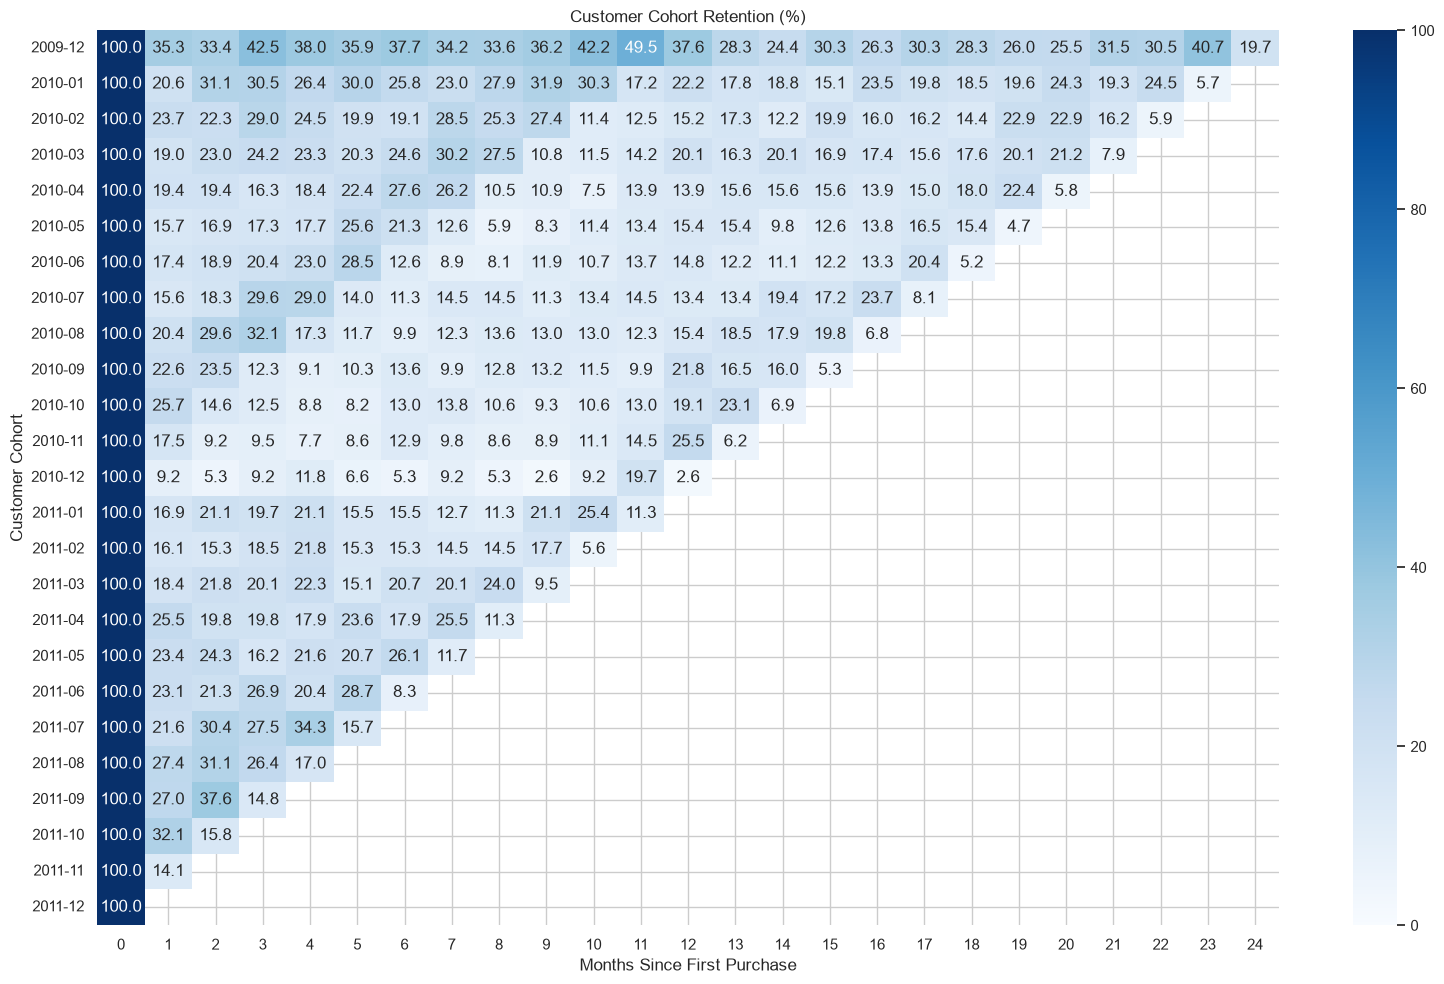

In [15]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title(
    "Customer Cohort Retention (%)"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Customer Cohort"
)

plt.tight_layout()
plt.show()

<h2>Save Retention Heatmap</h2>

In [16]:
plt.savefig(
    FIGURES_DIR / "cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

<h2>Calculate Average Retention</h2>

In [17]:
average_retention = (
    retention_percentage
    .mean(axis=0)
)

average_retention

CohortIndex
0    100.00
1     21.16
2     21.92
3     21.61
4     20.54
5     18.84
6     17.82
7     17.65
8     15.61
9     15.25
10    14.99
11    16.41
12    18.24
13    16.70
14    15.67
15    16.51
16    17.18
17    17.73
18    16.76
19    19.28
20    19.94
21    18.74
22    20.29
23    23.24
24    19.69
dtype: float64

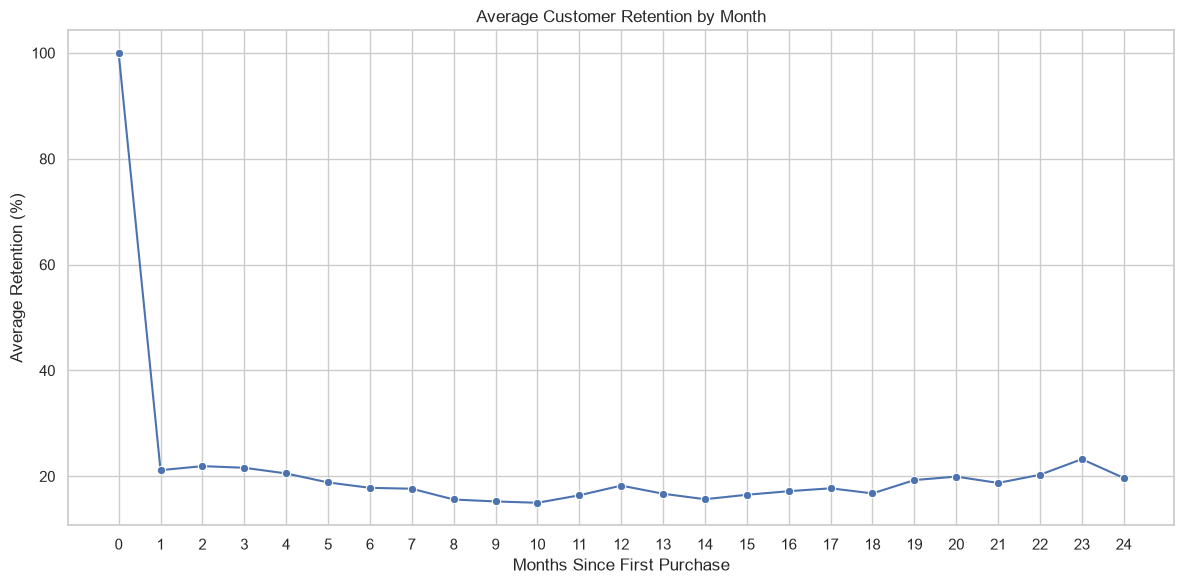

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=average_retention.index,
    y=average_retention.values,
    marker="o"
)

plt.title(
    "Average Customer Retention by Month"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Average Retention (%)"
)

plt.xticks(
    average_retention.index
)

plt.tight_layout()
plt.show()

<h2>Month 1 Retention</h2>

In [20]:
month_1_retention = (
    retention_percentage[1]
    .mean()
)

print(
    f"Average Month-1 Retention: "
    f"{month_1_retention:.2f}%"
)

Average Month-1 Retention: 21.16%


<h2>Month 3 Retention</h2>

In [21]:
if 3 in retention_percentage.columns:

    month_3_retention = (
        retention_percentage[3]
        .mean()
    )

    print(
        f"Average Month-3 Retention: "
        f"{month_3_retention:.2f}%"
    )

Average Month-3 Retention: 21.61%


<h2>Month 6 Retention</h2>

In [22]:
if 6 in retention_percentage.columns:

    month_6_retention = (
        retention_percentage[6]
        .mean()
    )

    print(
        f"Average Month-6 Retention: "
        f"{month_6_retention:.2f}%"
    )

Average Month-6 Retention: 17.82%


<h2>Cohort Size</h2>

In [23]:
cohort_size = (
    customer_cohort
    .groupby("CohortMonth")
    ["CustomerID"]
    .nunique()
)

cohort_size

CohortMonth
2009-12    955
2010-01    383
2010-02    376
2010-03    443
2010-04    294
2010-05    254
2010-06    270
2010-07    186
2010-08    162
2010-09    243
2010-10    377
2010-11    325
2010-12     76
2011-01     71
2011-02    124
2011-03    179
2011-04    106
2011-05    111
2011-06    108
2011-07    102
2011-08    106
2011-09    189
2011-10    221
2011-11    192
2011-12     28
Freq: M, Name: CustomerID, dtype: int64

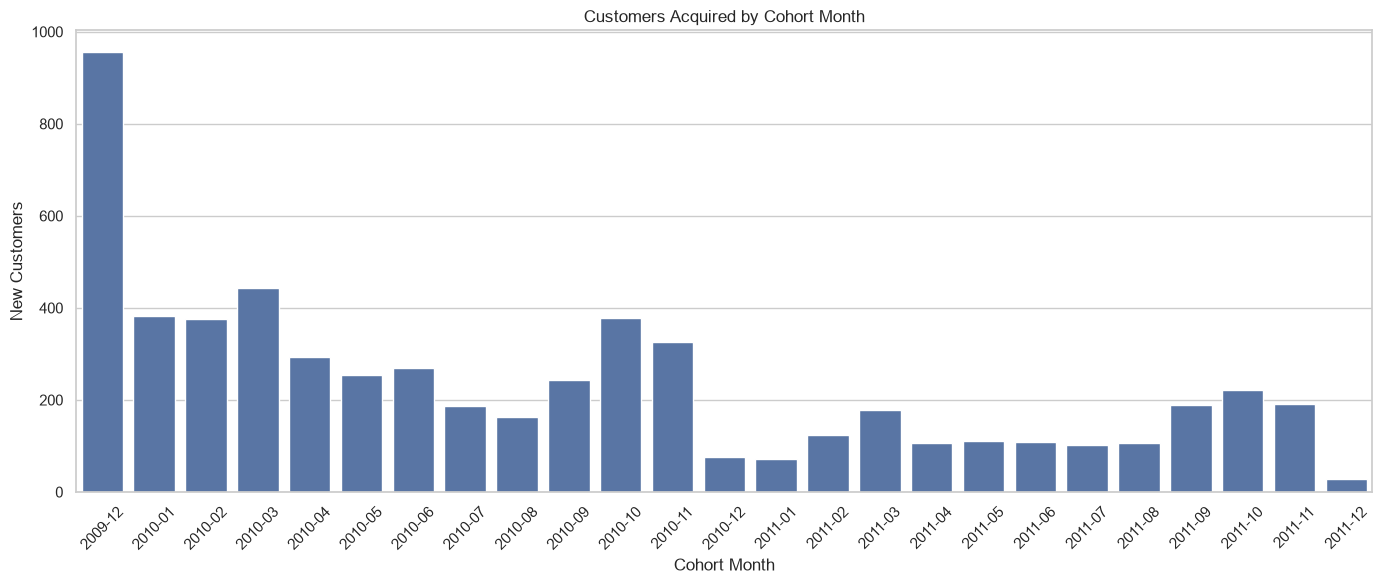

In [25]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=cohort_size.index.astype(str),
    y=cohort_size.values
)

plt.title(
    "Customers Acquired by Cohort Month"
)

plt.xlabel("Cohort Month")
plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Cohort Revenue</h2>

In [26]:
cohort_revenue = (
    cohort_df
    .groupby(
        [
            "CohortMonth",
            "CohortIndex"
        ]
    )["TotalPrice"]
    .sum()
    .reset_index()
)

cohort_revenue.head(20)

,CohortMonth,CohortIndex,TotalPrice
0,2009-12,0,"683,504.01"
1,2009-12,1,"394,723.98"
2,2009-12,2,"295,931.57"
3,2009-12,3,"378,663.12"
4,2009-12,4,"305,901.29"
5,2009-12,5,"305,066.66"
6,2009-12,6,"301,963.28"
7,2009-12,7,"312,812.83"
8,2009-12,8,"331,787.09"
9,2009-12,9,"391,539.48"


<h2>Revenue Matrix</h2>

In [27]:
revenue_matrix = (
    cohort_revenue
    .pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="TotalPrice"
    )
)

revenue_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,"683,504.01","394,723.98","295,931.57","378,663.12","305,901.29","305,066.66","301,963.28","312,812.83","331,787.09","391,539.48","460,559.66","571,512.94","343,430.89","308,663.89","215,062.67","256,376.35","163,073.42","286,209.39","279,982.71","254,244.84","273,833.38","376,156.51","414,950.35","446,632.65","163,414.18"
2010-01,"161,078.69","38,985.35","50,955.47","57,400.21","58,528.89","60,795.09","51,990.10","48,004.07","60,459.54","74,544.04","76,602.00","39,667.04","42,528.80","34,626.20","48,334.91","30,963.83","49,887.18","40,794.90","47,788.47","42,644.37","59,080.64","59,783.83","58,412.73","8,807.58",NaN
2010-02,"169,642.03","33,174.62","54,677.76","53,236.91","43,906.71","39,565.70","40,078.67","51,089.57","52,810.88","54,630.03","24,608.22","18,969.02","27,773.95","34,440.25","20,696.93","37,949.95","29,949.07","33,379.19","25,452.85","45,351.94","45,876.41","38,482.65","11,143.89",NaN,NaN
2010-03,"234,185.26","49,737.45","51,722.75","64,507.63","50,115.97","55,850.23","65,378.39","81,126.03","76,267.27","21,162.80","24,671.99","30,097.21","43,607.19","41,927.37","47,310.94","31,752.97","42,538.51","49,959.38","47,404.62","57,324.00","62,223.16","17,257.79",NaN,NaN,NaN
2010-04,"124,265.29","18,871.04","20,579.41","30,099.75","22,224.76","30,769.05","35,105.30","32,670.45","10,302.55","17,661.73","6,498.14","16,954.37","21,429.66","22,614.40","16,747.04","22,450.36","17,851.94","19,359.41","32,099.90","29,883.44","4,942.32",NaN,NaN,NaN,NaN
2010-05,"110,407.13","13,574.65","14,065.40","12,685.68","16,861.31","31,174.36","23,140.53","9,030.48","5,879.52","7,238.21","9,263.98","13,201.06","17,411.74","18,100.47","10,314.72","14,712.35","22,168.65","17,589.70","15,874.58","3,417.78",NaN,NaN,NaN,NaN,NaN
2010-06,"131,044.36","16,038.77","22,546.50","25,780.81","34,934.40","48,306.23","15,921.01","17,269.38","23,850.97","28,526.94","12,458.01","29,939.65","40,341.98","16,108.24","45,798.64","18,715.65","38,368.76","27,844.58","4,447.42",NaN,NaN,NaN,NaN,NaN,NaN
2010-07,"75,047.65","8,384.30","13,690.61","24,927.85","28,658.50","9,001.85","9,095.05","10,467.05","10,378.25","9,946.03","9,192.18","12,650.06","12,283.53","14,311.51","15,681.11","15,625.79","22,590.65","7,183.30",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,"60,663.30","13,797.99","23,029.07","23,403.83","14,214.98","5,428.84","5,303.23","7,279.92","9,854.03","9,831.21","7,242.49","6,992.87","11,195.27","18,300.55","19,485.88","19,734.22","5,620.11",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Revenue Heatmap</h2>

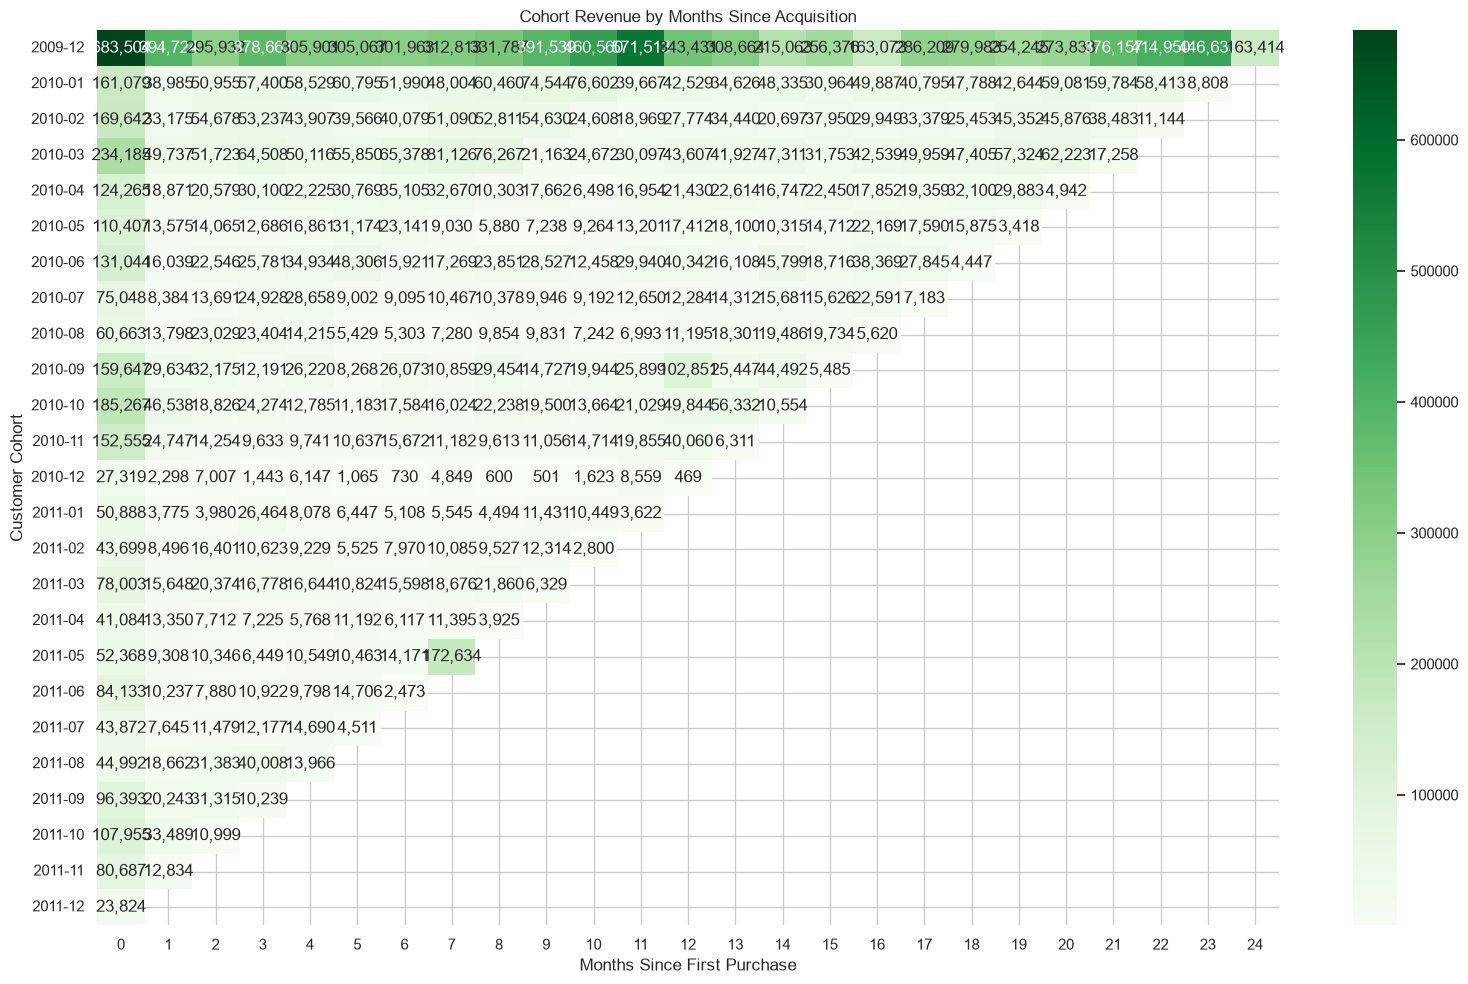

In [28]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    revenue_matrix,
    annot=True,
    fmt=",.0f",
    cmap="Greens"
)

plt.title(
    "Cohort Revenue by Months Since Acquisition"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Customer Cohort"
)

plt.tight_layout()
plt.show()

<h2>Revenue Retention Percentage</h2>

In [29]:
revenue_retention = (
    revenue_matrix
    .div(
        revenue_matrix.iloc[:, 0],
        axis=0
    )
    * 100
)

revenue_retention.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,57.75,43.30,55.40,44.75,44.63,44.18,45.77,48.54,57.28,67.38,83.62,50.25,45.16,31.46,37.51,23.86,41.87,40.96,37.20,40.06,55.03,60.71,65.34,23.91
2010-01,100.00,24.20,31.63,35.63,36.34,37.74,32.28,29.80,37.53,46.28,47.56,24.63,26.40,21.50,30.01,19.22,30.97,25.33,29.67,26.47,36.68,37.11,36.26,5.47,NaN
2010-02,100.00,19.56,32.23,31.38,25.88,23.32,23.63,30.12,31.13,32.20,14.51,11.18,16.37,20.30,12.20,22.37,17.65,19.68,15.00,26.73,27.04,22.68,6.57,NaN,NaN
2010-03,100.00,21.24,22.09,27.55,21.40,23.85,27.92,34.64,32.57,9.04,10.54,12.85,18.62,17.90,20.20,13.56,18.16,21.33,20.24,24.48,26.57,7.37,NaN,NaN,NaN
2010-04,100.00,15.19,16.56,24.22,17.88,24.76,28.25,26.29,8.29,14.21,5.23,13.64,17.25,18.20,13.48,18.07,14.37,15.58,25.83,24.05,3.98,NaN,NaN,NaN,NaN
2010-05,100.00,12.30,12.74,11.49,15.27,28.24,20.96,8.18,5.33,6.56,8.39,11.96,15.77,16.39,9.34,13.33,20.08,15.93,14.38,3.10,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,12.24,17.21,19.67,26.66,36.86,12.15,13.18,18.20,21.77,9.51,22.85,30.78,12.29,34.95,14.28,29.28,21.25,3.39,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,11.17,18.24,33.22,38.19,11.99,12.12,13.95,13.83,13.25,12.25,16.86,16.37,19.07,20.89,20.82,30.10,9.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,22.75,37.96,38.58,23.43,8.95,8.74,12.00,16.24,16.21,11.94,11.53,18.45,30.17,32.12,32.53,9.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Revenue Retention Heatmap</h2>

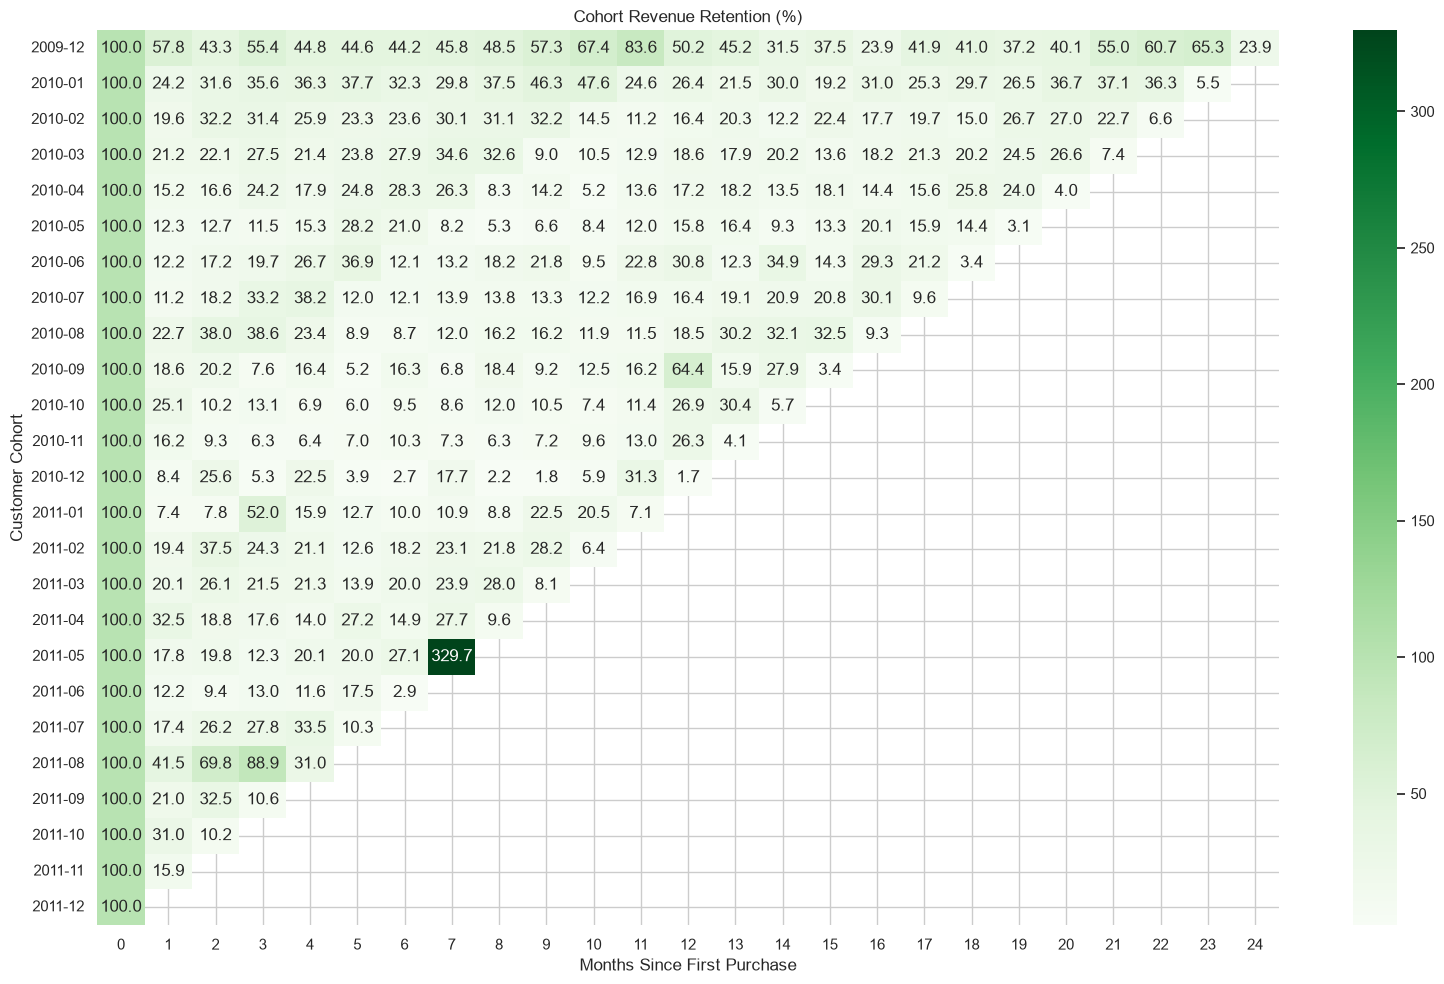

In [30]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    revenue_retention,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.title(
    "Cohort Revenue Retention (%)"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Customer Cohort"
)

plt.tight_layout()
plt.show()

<h2>Average Revenue Retention</h2>

In [31]:
average_revenue_retention = (
    revenue_retention.mean(axis=0)
)

average_revenue_retention

CohortIndex
0    100.00
1     20.87
2     24.14
3     26.25
4     22.41
5     18.83
6     18.01
7     37.21
8     18.75
9     19.02
10    16.65
11    20.58
12    25.35
13    20.96
14    21.66
15    19.51
16    21.53
17    21.32
18    21.35
19    23.67
20    26.87
21    30.55
22    34.51
23    35.41
24    23.91
dtype: float64

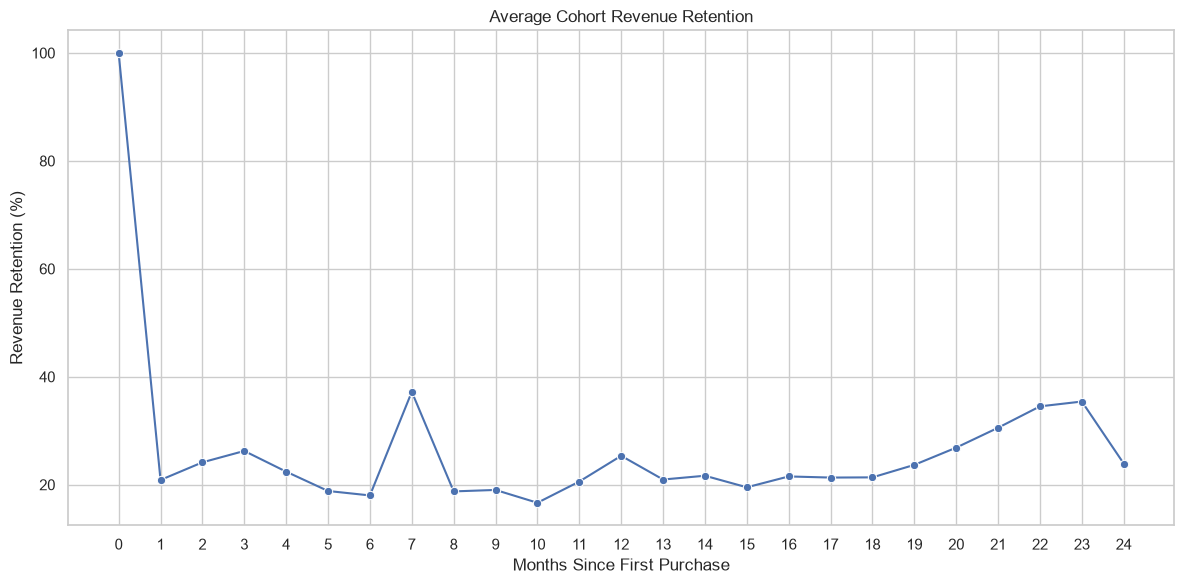

In [32]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=average_revenue_retention.index,
    y=average_revenue_retention.values,
    marker="o"
)

plt.title(
    "Average Cohort Revenue Retention"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Revenue Retention (%)"
)

plt.xticks(
    average_revenue_retention.index
)

plt.tight_layout()
plt.show()

<h2>Compare Customer vs Revenue Retention</h2>

In [33]:
comparison_retention = pd.DataFrame({
    "CustomerRetention": average_retention,
    "RevenueRetention": average_revenue_retention
})

comparison_retention

,CustomerRetention,RevenueRetention
CohortIndex,,
0,100.00,100.00
1,21.16,20.87
2,21.92,24.14
3,21.61,26.25
4,20.54,22.41
5,18.84,18.83
6,17.82,18.01
7,17.65,37.21
8,15.61,18.75


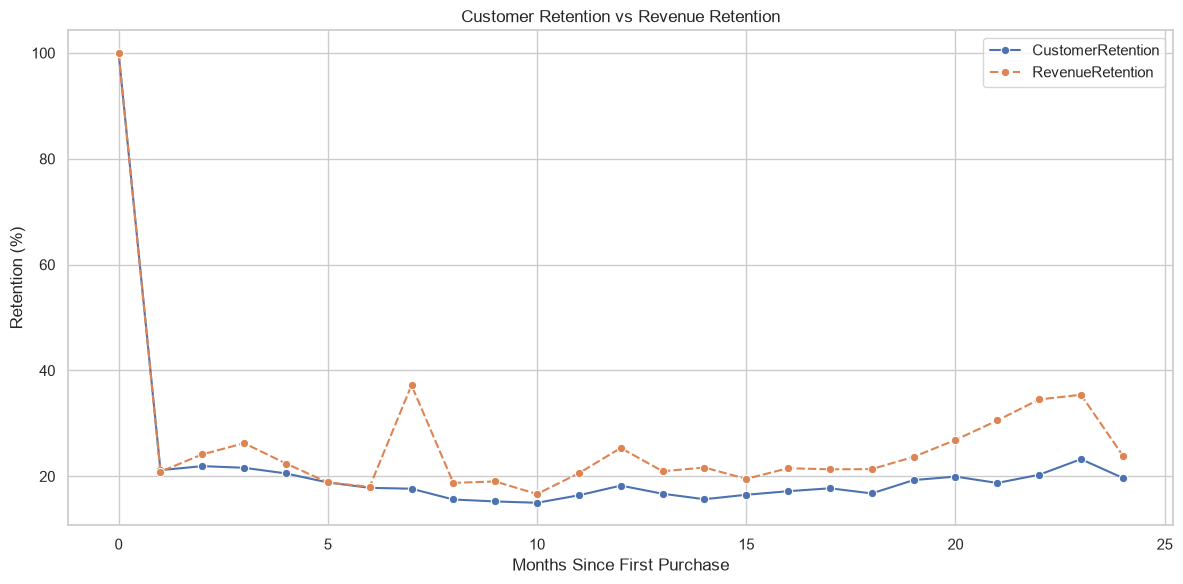

In [34]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=comparison_retention,
    marker="o"
)

plt.title(
    "Customer Retention vs Revenue Retention"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Retention (%)"
)

plt.tight_layout()
plt.show()

<h2>Cohort AOV</h2>

In [35]:
cohort_aov = (
    cohort_df
    .groupby(
        [
            "CohortMonth",
            "CohortIndex"
        ]
    )
    .agg(
        Revenue=("TotalPrice", "sum"),
        Orders=("Invoice", "nunique")
    )
)

cohort_aov["AOV"] = (
    cohort_aov["Revenue"] /
    cohort_aov["Orders"]
)

cohort_aov.head(20)

Revenue  Orders    AOV
CohortMonth CohortIndex                          
2009-12     0           683,504.01    1512 452.05
            1           394,723.98     569 693.72
            2           295,931.57     564 524.70
            3           378,663.12     717 528.12
            4           305,901.29     629 486.33
            5           305,066.66     610 500.11
            6           301,963.28     636 474.79
            7           312,812.83     597 523.97
            8           331,787.09     549 604.35
            9           391,539.48     680 575.79
            10          460,559.66     757 608.40
            11          571,512.94    1007 567.54
            12          343,430.89     718 478.32
            13          308,663.89     424 727.98
            14          215,062.67     371 579.68
            15          256,376.35     484 529.70
            16          163,073.42     400 407.68
            17          286,209.39     546 524.19
            18          279,982.71     487 574.91
            19          254,244.84     449 566.25

<h2>AOV Matrix</h2>

In [36]:
aov_matrix = (
    cohort_aov
    .reset_index()
    .pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="AOV"
    )
)

aov_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,452.05,693.72,524.70,528.12,486.33,500.11,474.79,523.97,604.35,575.79,608.40,567.54,478.32,727.98,579.68,529.70,407.68,524.19,574.91,566.25,648.89,681.44,725.44,543.35,581.55
2010-01,363.61,389.85,306.96,401.40,440.07,382.36,379.49,400.03,419.86,465.90,442.79,400.68,416.95,398.00,478.56,436.11,408.91,416.27,503.04,444.21,468.89,586.12,384.29,338.75,NaN
2010-02,382.94,296.20,463.37,385.77,375.27,391.74,426.37,375.66,443.79,369.12,455.71,321.51,420.82,453.16,390.51,351.39,369.74,427.94,348.67,408.58,424.78,400.86,384.27,NaN,NaN
2010-03,442.69,436.29,356.71,405.71,357.97,439.77,457.19,455.76,421.37,306.71,440.57,418.02,427.52,465.86,415.01,352.81,425.39,561.34,504.30,540.79,414.82,420.92,NaN,NaN,NaN
2010-04,382.35,285.92,302.64,470.31,326.83,375.23,344.17,323.47,264.17,464.78,249.93,385.33,437.34,418.79,315.98,431.74,343.31,387.19,465.22,324.82,274.57,NaN,NaN,NaN,NaN
2010-05,387.39,282.81,299.26,264.29,271.96,380.18,321.40,244.07,279.98,301.59,289.50,347.40,362.74,420.94,312.57,387.17,481.93,351.79,288.63,227.85,NaN,NaN,NaN,NaN,NaN
2010-06,422.72,276.53,357.88,390.62,459.66,468.99,306.17,639.61,851.82,792.41,346.06,611.01,823.31,413.03,"1,205.23",456.48,872.02,339.57,317.67,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,316.66,246.60,273.81,341.48,333.24,257.20,303.17,327.10,296.52,310.81,287.26,372.06,341.21,408.90,326.69,363.39,332.22,359.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,319.28,306.62,338.66,285.41,346.71,271.44,331.45,269.63,364.96,351.11,289.70,268.96,373.18,571.89,556.74,481.32,468.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>AOV Heatmap</h2>

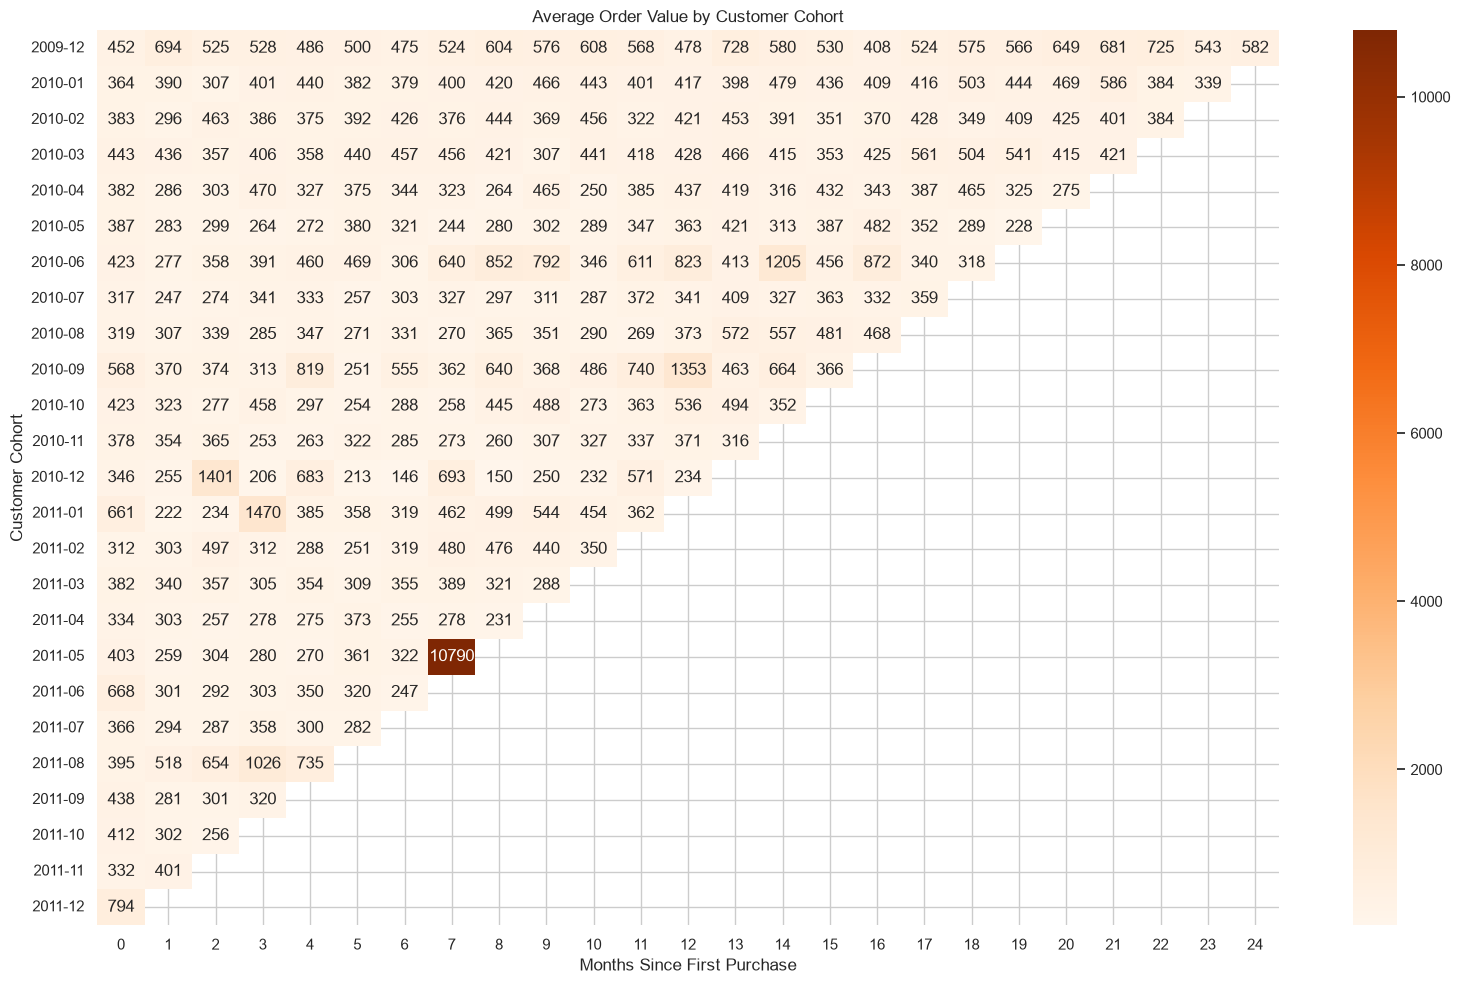

In [37]:
plt.figure(figsize=(16, 10))

sns.heatmap(
    aov_matrix,
    annot=True,
    fmt=".0f",
    cmap="Oranges"
)

plt.title(
    "Average Order Value by Customer Cohort"
)

plt.xlabel(
    "Months Since First Purchase"
)

plt.ylabel(
    "Customer Cohort"
)

plt.tight_layout()
plt.show()

<h2>Identify Best Cohorts</h2>

In [39]:
if 1 in retention_percentage.columns:

    best_month_1_cohorts = (
        retention_percentage[1]
        .sort_values(
            ascending=False
        )
    )

best_month_1_cohorts.head(10)

CohortMonth
2009-12   35.29
2011-10   32.13
2011-08   27.36
2011-09   26.98
2010-10   25.73
2011-04   25.47
2010-02   23.67
2011-05   23.42
2011-06   23.15
2010-09   22.63
Freq: M, Name: 1, dtype: float64

<h2>Worst Cohorts</h2>

In [41]:
if 1 in retention_percentage.columns:

    worst_month_1_cohorts = (
        retention_percentage[1]
        .sort_values(
            ascending=True
        )
    )

worst_month_1_cohorts.head(10)

CohortMonth
2010-12    9.21
2011-11   14.06
2010-07   15.59
2010-05   15.75
2011-02   16.13
2011-01   16.90
2010-06   17.41
2010-11   17.54
2011-03   18.44
2010-03   18.96
Freq: M, Name: 1, dtype: float64

<h2>Long-Term Retention</h2>

In [43]:
if 6 in retention_percentage.columns:

    month_6_cohorts = (
        retention_percentage[6]
        .dropna()
        .sort_values(
            ascending=False
        )
    )

month_6_cohorts

CohortMonth
2009-12   37.70
2010-04   27.55
2011-05   26.13
2010-01   25.85
2010-03   24.60
2010-05   21.26
2011-03   20.67
2010-02   19.15
2011-04   17.92
2011-01   15.49
2011-02   15.32
2010-09   13.58
2010-10   13.00
2010-11   12.92
2010-06   12.59
2010-07   11.29
2010-08    9.88
2011-06    8.33
2010-12    5.26
Freq: M, Name: 6, dtype: float64

<h2>Cohort Lifetime Revenue</h2>

In [44]:
cumulative_revenue = (
    revenue_matrix
    .cumsum(axis=1)
)

cumulative_revenue

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,"683,504.01","1,078,227.99","1,374,159.56","1,752,822.68","2,058,723.97","2,363,790.63","2,665,753.91","2,978,566.74","3,310,353.83","3,701,893.31","4,162,452.97","4,733,965.92","5,077,396.80","5,386,060.69","5,601,123.36","5,857,499.71","6,020,573.14","6,306,782.53","6,586,765.24","6,841,010.08","7,114,843.46","7,490,999.97","7,905,950.32","8,352,582.97","8,515,997.15"
2010-01,"161,078.69","200,064.04","251,019.51","308,419.72","366,948.61","427,743.70","479,733.80","527,737.87","588,197.41","662,741.45","739,343.45","779,010.49","821,539.29","856,165.49","904,500.40","935,464.23","985,351.41","1,026,146.31","1,073,934.78","1,116,579.15","1,175,659.79","1,235,443.62","1,293,856.35","1,302,663.93",NaN
2010-02,"169,642.03","202,816.65","257,494.41","310,731.32","354,638.03","394,203.73","434,282.40","485,371.98","538,182.85","592,812.89","617,421.10","636,390.12","664,164.07","698,604.32","719,301.26","757,251.20","787,200.27","820,579.46","846,032.31","891,384.25","937,260.66","975,743.31","986,887.20",NaN,NaN
2010-03,"234,185.26","283,922.71","335,645.46","400,153.09","450,269.06","506,119.29","571,497.68","652,623.71","728,890.98","750,053.78","774,725.77","804,822.98","848,430.17","890,357.54","937,668.48","969,421.45","1,011,959.96","1,061,919.34","1,109,323.96","1,166,647.96","1,228,871.12","1,246,128.91",NaN,NaN,NaN
2010-04,"124,265.29","143,136.33","163,715.74","193,815.49","216,040.25","246,809.30","281,914.60","314,585.05","324,887.60","342,549.33","349,047.47","366,001.84","387,431.50","410,045.90","426,792.94","449,243.30","467,095.24","486,454.65","518,554.55","548,437.99","553,380.31",NaN,NaN,NaN,NaN
2010-05,"110,407.13","123,981.78","138,047.18","150,732.86","167,594.17","198,768.53","221,909.06","230,939.54","236,819.06","244,057.27","253,321.25","266,522.31","283,934.05","302,034.52","312,349.24","327,061.59","349,230.24","366,819.94","382,694.52","386,112.30",NaN,NaN,NaN,NaN,NaN
2010-06,"131,044.36","147,083.13","169,629.63","195,410.44","230,344.84","278,651.07","294,572.08","311,841.46","335,692.43","364,219.37","376,677.38","406,617.03","446,959.01","463,067.25","508,865.89","527,581.54","565,950.30","593,794.88","598,242.30",NaN,NaN,NaN,NaN,NaN,NaN
2010-07,"75,047.65","83,431.95","97,122.56","122,050.41","150,708.91","159,710.76","168,805.81","179,272.86","189,651.11","199,597.14","208,789.32","221,439.38","233,722.91","248,034.42","263,715.53","279,341.32","301,931.97","309,115.27",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,"60,663.30","74,461.29","97,490.36","120,894.19","135,109.17","140,538.01","145,841.24","153,121.16","162,975.19","172,806.40","180,048.89","187,041.76","198,237.03","216,537.58","236,023.46","255,757.68","261,377.79",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2>Average Revenue Per Acquired Customer</h2>

In [45]:
cohort_total_revenue = (
    cohort_df
    .groupby("CohortMonth")["TotalPrice"]
    .sum()
)

cohort_revenue_per_customer = (
    cohort_total_revenue /
    cohort_size
)

cohort_revenue_per_customer.sort_values(
    ascending=False
)

CohortMonth
2009-12   8,917.27
2010-01   3,401.21
2010-03   2,812.93
2010-02   2,624.70
2011-05   2,579.18
2010-09   2,359.53
2010-06   2,215.71
2011-01   1,975.78
2010-04   1,882.25
2010-07   1,661.91
2010-08   1,613.44
2010-05   1,520.13
2011-08   1,405.76
2010-10   1,394.28
2011-06   1,297.68
2011-03   1,233.14
2011-02   1,102.18
2010-11   1,077.01
2011-04   1,016.69
2011-07     925.23
2011-12     850.87
2011-09     836.99
2010-12     823.81
2011-10     689.79
2011-11     487.09
Freq: M, dtype: float64

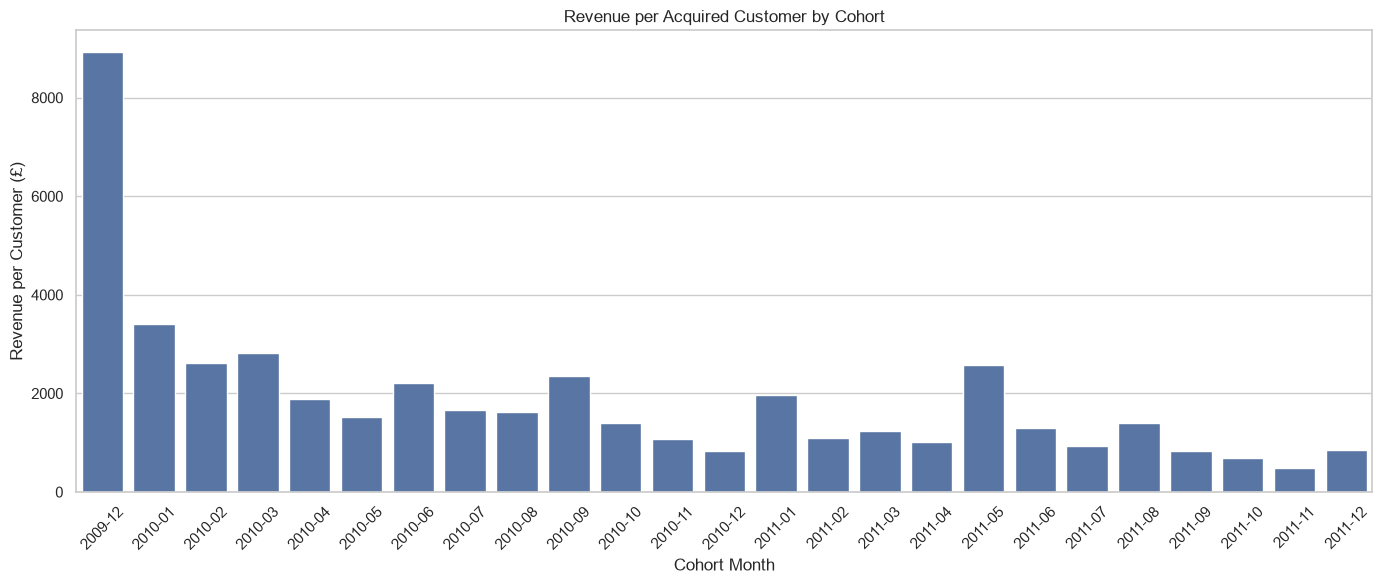

In [46]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=cohort_revenue_per_customer.index.astype(str),
    y=cohort_revenue_per_customer.values
)

plt.title(
    "Revenue per Acquired Customer by Cohort"
)

plt.xlabel("Cohort Month")
plt.ylabel("Revenue per Customer (£)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<h2>Save Cohort Outputs</h2>

In [47]:
retention_percentage.to_csv(
    REPORTS_DIR /
    "cohort_customer_retention.csv"
)

revenue_retention.to_csv(
    REPORTS_DIR /
    "cohort_revenue_retention.csv"
)

revenue_matrix.to_csv(
    REPORTS_DIR /
    "cohort_revenue_matrix.csv"
)

cohort_size.to_csv(
    REPORTS_DIR /
    "cohort_sizes.csv"
)

aov_matrix.to_csv(
    REPORTS_DIR /
    "cohort_aov_matrix.csv"
)

<h2>Save Important Figures</h2>

In [48]:
plt.savefig(
    FIGURES_DIR /
    "cohort_revenue_retention.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

<h2>Create Cohort Summary</h2>

In [49]:
cohort_summary = pd.DataFrame({
    "CohortSize": cohort_size
})

if 1 in retention_percentage.columns:
    cohort_summary["Month1Retention"] = (
        retention_percentage[1]
    )

if 3 in retention_percentage.columns:
    cohort_summary["Month3Retention"] = (
        retention_percentage[3]
    )

if 6 in retention_percentage.columns:
    cohort_summary["Month6Retention"] = (
        retention_percentage[6]
    )

cohort_summary["TotalRevenue"] = (
    cohort_total_revenue
)

cohort_summary["RevenuePerCustomer"] = (
    cohort_revenue_per_customer
)

cohort_summary

,CohortSize,Month1Retention,Month3Retention,Month6Retention,TotalRevenue,RevenuePerCustomer
CohortMonth,,,,,,
2009-12,955,35.29,42.51,37.70,"8,515,997.15","8,917.27"
2010-01,383,20.63,30.55,25.85,"1,302,663.93","3,401.21"
2010-02,376,23.67,28.99,19.15,"986,887.20","2,624.70"
2010-03,443,18.96,24.15,24.60,"1,246,128.91","2,812.93"
2010-04,294,19.39,16.33,27.55,"553,380.31","1,882.25"
2010-05,254,15.75,17.32,21.26,"386,112.30","1,520.13"
2010-06,270,17.41,20.37,12.59,"598,242.30","2,215.71"
2010-07,186,15.59,29.57,11.29,"309,115.27","1,661.91"
2010-08,162,20.37,32.10,9.88,"261,377.79","1,613.44"


In [50]:
cohort_summary.to_csv(
    REPORTS_DIR /
    "cohort_summary.csv"
)

<h2>Final Validation</h2>

In [51]:
print("=" * 60)
print("COHORT ANALYSIS COMPLETE")
print("=" * 60)

print(
    f"Cohorts analyzed: "
    f"{len(cohort_size)}"
)

print(
    f"Total customers: "
    f"{customer_cohort['CustomerID'].nunique():,}"
)

if 1 in average_retention.index:
    print(
        f"Average Month-1 retention: "
        f"{average_retention[1]:.2f}%"
    )

if 3 in average_retention.index:
    print(
        f"Average Month-3 retention: "
        f"{average_retention[3]:.2f}%"
    )

if 6 in average_retention.index:
    print(
        f"Average Month-6 retention: "
        f"{average_retention[6]:.2f}%"
    )

print("=" * 60)

COHORT ANALYSIS COMPLETE
Cohorts analyzed: 25
Total customers: 5,881
Average Month-1 retention: 21.16%
Average Month-3 retention: 21.61%
Average Month-6 retention: 17.82%


RAW TRANSACTIONS
       │
       ▼
DATA CLEANING
       │
       ▼
EDA
       │
       ├───────────────┐
       ▼               ▼
PRODUCT ANALYSIS   CUSTOMER ANALYSIS
                       │
                ┌──────┴──────┐
                ▼             ▼
              RFM          COHORTS
                │             │
                ▼             ▼
          SEGMENTATION     RETENTION
                │             │
          ┌─────┴─────┐       │
          ▼           ▼       ▼
       RULE-BASED  K-MEANS  LIFECYCLE